In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
wine = load_wine()

X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

print(X.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [3]:
X.info()


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [6]:
print(X.describe())


          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

In [7]:

print(X.isnull().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Elbow Method

In [9]:
inertia = []

K = range(1,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

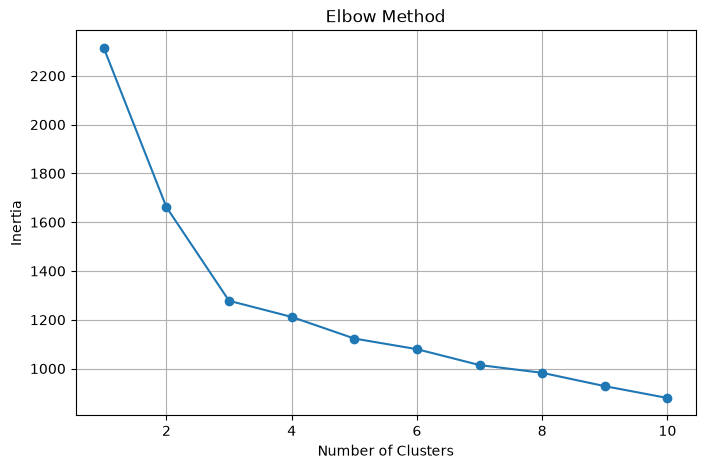

In [10]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

KMean clustering

In [11]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)

In [12]:
print(labels)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [13]:
print(kmeans.cluster_centers_)

[[-0.92607185 -0.39404154 -0.49451676  0.17060184 -0.49171185 -0.07598265
   0.02081257 -0.03353357  0.0582655  -0.90191402  0.46180361  0.27076419
  -0.75384618]
 [ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
  -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
  -0.40708796]
 [ 0.83523208 -0.30380968  0.36470604 -0.61019129  0.5775868   0.88523736
   0.97781956 -0.56208965  0.58028658  0.17106348  0.47398365  0.77924711
   1.12518529]]


In [14]:
score = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.2848589191898987


PCA 

In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [16]:
print(pca.explained_variance_ratio_)

[0.36198848 0.1920749 ]


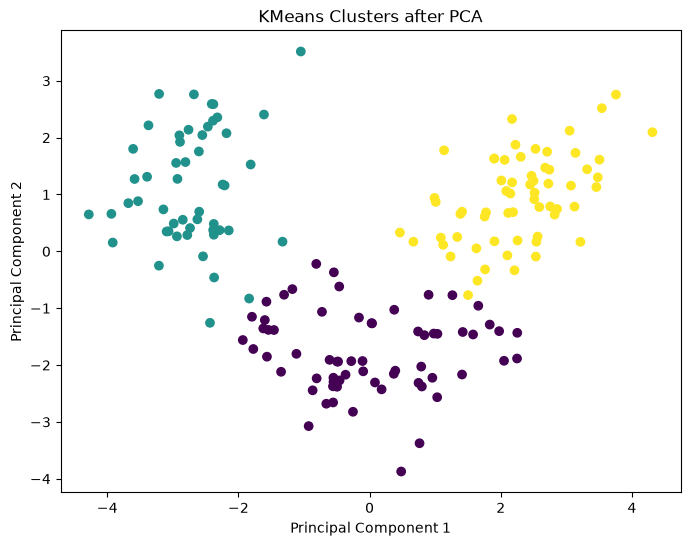

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("KMeans Clusters after PCA")

plt.show()

DBSCAN

In [18]:
dbscan = DBSCAN(
    eps=2,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

print(db_labels)

[ 0  0  0  0 -1  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0 -1  0  0
  0 -1  0  0  0  0 -1  0  0  0  0  0  0  0  0 -1  0 -1  0 -1  0 -1 -1  0
  0  0 -1  0  0  0  0  0  0  0  0 -1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1  0  0 -1 -1 -1  0  1 -1  1  1  1  1  1 -1 -1 -1
 -1  0 -1 -1 -1  0  0  0  0 -1  0  1  0 -1 -1  0 -1  1  0 -1  0  0 -1 -1
  0 -1 -1 -1 -1  0  0 -1  0 -1 -1  2  2  2 -1 -1 -1 -1 -1  3  3 -1  3 -1
 -1 -1 -1  4  4 -1 -1 -1 -1 -1 -1 -1  4 -1 -1 -1  4  3  3  2  4 -1 -1  4
 -1 -1  2  4  4 -1  4 -1 -1 -1]


In [19]:
print(np.unique(db_labels))

[-1  0  1  2  3  4]


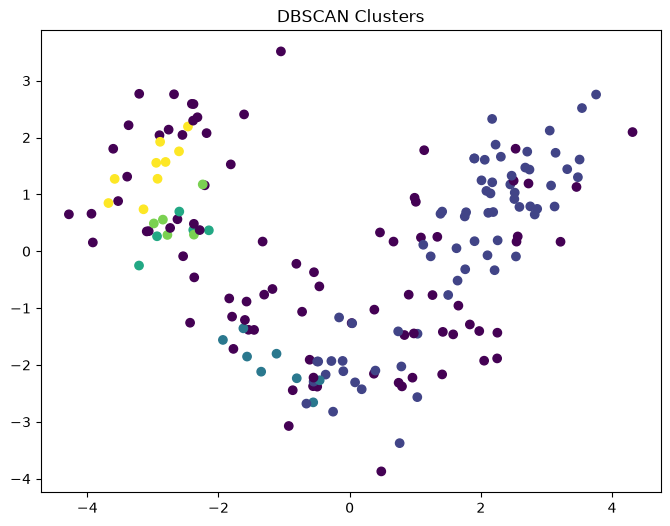

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=db_labels
)

plt.title("DBSCAN Clusters")

plt.show()

Hierarchical clustering 

In [21]:
hierarchical = AgglomerativeClustering(
    n_clusters=3
)

hier_labels = hierarchical.fit_predict(X_scaled)

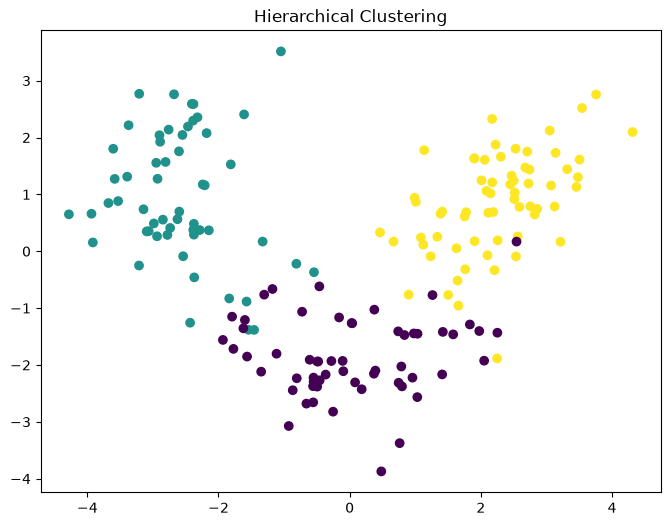

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hier_labels
)

plt.title("Hierarchical Clustering")

plt.show()

In [23]:
pca95 = PCA(
    n_components=0.95
)

X_new = pca95.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)

print("Reduced Shape:", X_new.shape)

Original Shape: (178, 13)
Reduced Shape: (178, 10)


In [24]:
print(pca95.explained_variance_ratio_)

[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019]


In [25]:
print(np.sum(pca95.explained_variance_ratio_))

0.9616971684450644


In [26]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42
)

pca_labels = kmeans_pca.fit_predict(X_new)

In [27]:
original_score = silhouette_score(
    X_scaled,
    labels
)

reduced_score = silhouette_score(
    X_new,
    pca_labels
)

print("Original Data Score :", original_score)

print("PCA Data Score :", reduced_score)

Original Data Score : 0.2848589191898987
PCA Data Score : 0.29867482943692886


Pipeline building 


In [28]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("kmeans", KMeans(n_clusters=3, random_state=42))
])

pipeline.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['alcohol','malic_acid','ash',...,'hue','od280/od315_of_diluted_wines', 'proline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [29]:
print("=" * 40)

print("Number of Samples :", X.shape[0])

print("Original Features :", X.shape[1])

print("Reduced Features :", X_new.shape[1])

print("KMeans Inertia :", kmeans.inertia_)

print("Silhouette Score :", original_score)

print("Variance Retained :", np.sum(pca95.explained_variance_ratio_))

print("=" * 40)

Number of Samples : 178
Original Features : 13
Reduced Features : 10
KMeans Inertia : 1277.928488844642
Silhouette Score : 0.2848589191898987
Variance Retained : 0.9616971684450644


In [30]:
from sklearn.manifold import TSNE

In [31]:
wine = load_wine()

Z = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

y = wine.target

print(Z.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [32]:
scaler = StandardScaler()

Z_scaled = scaler.fit_transform(Z)

In [33]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    random_state=42
)

Z_tsne = tsne.fit_transform(Z_scaled)

In [35]:
print(Z_tsne.shape)

(178, 2)


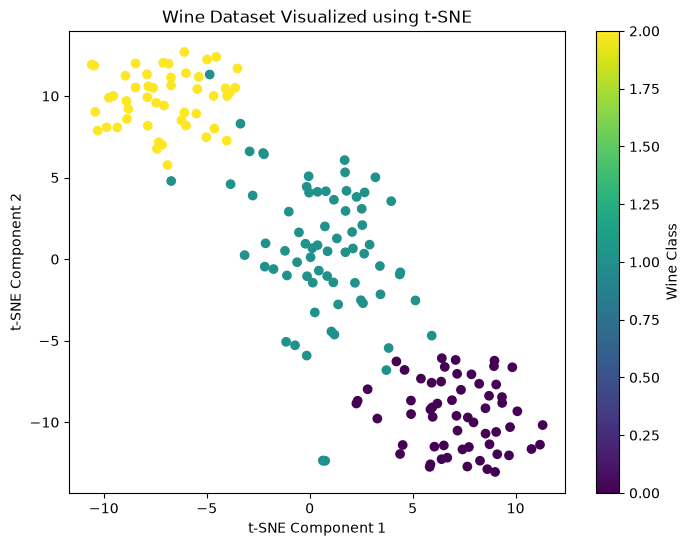

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    Z_tsne[:,0],
    Z_tsne[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Wine Dataset Visualized using t-SNE")

plt.colorbar(label="Wine Class")

plt.show()

In [38]:
from sklearn.decomposition import PCA

In [39]:
pca = PCA(n_components=2)

Z_pca = pca.fit_transform(Z_scaled)

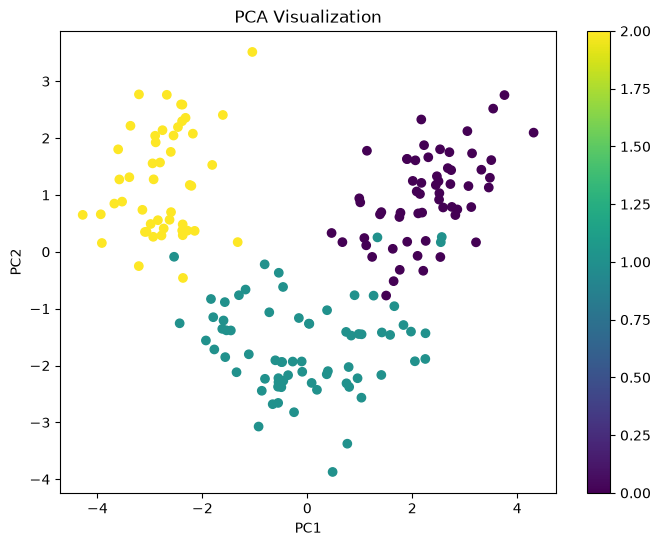

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    Z_pca[:,0],
    Z_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")

plt.colorbar()

plt.show()

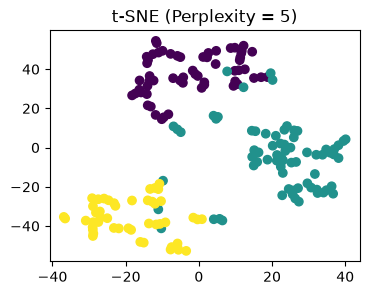

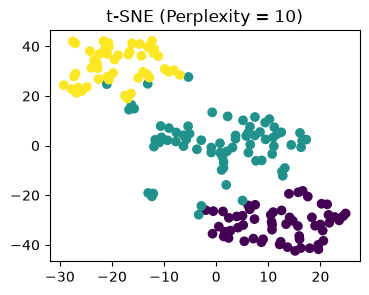

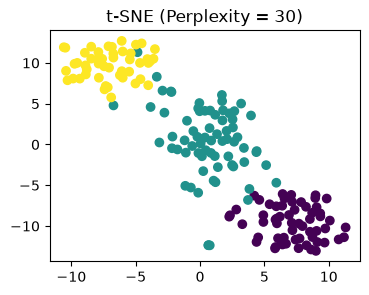

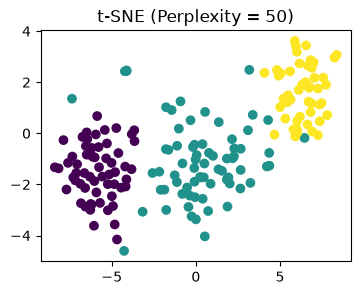

In [43]:
for p in [5, 10, 30, 50]:
    
    tsne = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate='auto',
        random_state=42
    )
    
    X_embedded = tsne.fit_transform(X_scaled)

    plt.figure(figsize=(4,3))

    plt.scatter(
        X_embedded[:,0],
        X_embedded[:,1],
        c=y,
        cmap='viridis'
    )

    plt.title(f"t-SNE (Perplexity = {p})")

    plt.show()